In [5]:
import operator
from typing import Annotated, List, TypedDict, Union, Dict
from datetime import datetime

from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END

# --- 1. DEFINISI STATE (DATA PERSISTENCE) ---

class AgentState(TypedDict):
    """Menyimpan status percakapan dan metadata customer."""
    messages: Annotated[List[BaseMessage], operator.add]
    user_profile: Dict[str, str] # source, level (awam/paham), category (pribadi/bisnis)
    needs: List[str]             # misal: ["pantau bbm", "suhu"]
    priority_level: int          # 1: High (G-Meet), 2: Medium (E-comm), 3: Low (Sales)
    next_action: str             # Placeholder untuk node selanjutnya
    last_internal_ping: datetime # Untuk monitoring slow response

# --- 2. DEFINISI AI AGENT TOOLS ---

@tool
def get_product_catalog(product_type: str):
    """
    Mengambil URL katalog (PDF/Gambar) berdasarkan tipe produk. 
    Hanya mengirimkan katalog tanpa mencantumkan harga di awal.
    """
    # Placeholder: Logic to fetch from database/cloud storage
    catalogs = {
        "OBU F": "https://orin.id/catalog/obu-f-fleet.pdf",
        "General": "https://orin.id/catalog/general-solutions.pdf"
    }
    return catalogs.get(product_type, catalogs["General"])

@tool
def check_ecommerce_traffic_priority():
    """
    Mengecek platform e-commerce mana (Shopee/Tokopedia/TikTok) yang 
    saat ini memiliki traffic rendah atau sedang membutuhkan boost penjualan.
    """
    # Placeholder: Logic integrasi dengan API dashboard marketing
    return "Shopee (ORIN Official)"

@tool
def schedule_gmeet_session(customer_data: dict):
    """
    Membuat undangan Google Meet otomatis untuk prospek High Potential (Bisnis/Fleet).
    Menghubungkan customer dengan Tim Expert.
    """
    # Placeholder: Integration with Google Calendar API
    return "Link G-Meet berhasil dibuat: https://meet.google.com/abc-defg-hij"

@tool
def route_to_sales_team(category: str, difficulty: str = "normal"):
    """
    Mendistribusikan lead ke tim sales menggunakan sistem rolling (A-E).
    Jika difficulty='complex', akan langsung diarahkan ke Senior (Gustama/Oktav).
    """
    # Placeholder: Logic database untuk tracking 'Next Turn' Sales
    seniors = ["Gustama", "Oktav"]
    juniors = ["Sales A", "Sales B", "Sales C", "Sales D", "Sales E"]
    
    if category == "Bisnis" or difficulty == "complex":
        return f"Lead diarahkan ke Senior: {seniors[0]}"
    return f"Lead diarahkan ke: {juniors[1]} (Rolling System)"

@tool
def save_contact_to_crm(profile_data: dict):
    """
    Menyimpan otomatis kontak, sumber lead, dan kategori user ke database CRM ORIN.
    """
    # Placeholder: Integration with PostgreSQL/HubSpot/Salesforce
    return "Success: Contact saved."

# --- 3. DEFINISI NODES (LOGIKA BERPIKIR) ---

class HanaNodes:
    def __init__(self, model):
        self.model = model

    def profiler_node(self, state: AgentState):
        """Menganalisis pesan pertama untuk profiling (Sumber & Kategori)."""
        last_message = state['messages'][-1].content
        # Logic: LLM mengekstrak informasi profiling
        # Contoh output simulasi:
        state['user_profile'] = {
            "source": "TikTok",
            "category": "Bisnis", 
            "level": "Awam"
        }
        return {"user_profile": state['user_profile']}

    def educational_node(self, state: AgentState):
        """Memberikan rekomendasi produk spesifik seperti OBU F."""
        # Hana merekomendasikan berdasarkan profil
        recommendation = "Berdasarkan kebutuhan armada Anda, saya sarankan OBU F yang bisa memantau BBM & Suhu secara real-time."
        catalog_url = get_product_catalog.invoke("OBU F")
        return {"messages": [AIMessage(content=f"{recommendation}\nKatalog: {catalog_url}")]}

    def strategy_node(self, state: AgentState):
        """Menentukan Call to Action (CTA) berdasarkan kategori user."""
        profile = state['user_profile']
        
        if profile['category'] == "Bisnis":
            state['priority_level'] = 1
            cta = "Saran: Jadwalkan G-Meet dengan tim expert kami untuk demo unit."
        elif "beli" in state['messages'][-1].content.lower():
            state['priority_level'] = 2
            platform = check_ecommerce_traffic_priority.invoke({})
            cta = f"Silakan transaksi melalui {platform} kami untuk promo minggu ini."
        else:
            state['priority_level'] = 3
            cta = "Saya akan hubungkan Anda dengan tim Sales kami untuk penawaran harga."
            
        return {"messages": [AIMessage(content=cta)], "priority_level": state['priority_level']}

    # Perbaikan di dalam HanaNodes class
    def dispatch_node(self, state: AgentState):
        """Handoff ke manusia atau sistem booking."""
        profile = state['user_profile']
        
        if state['priority_level'] == 1:
            # PERBAIKAN: Masukkan ke dalam dictionary dengan key 'customer_data'
            res = schedule_gmeet_session.invoke({"customer_data": profile})
        else:
            # Pastikan argumen 'category' sesuai dengan definisi tool
            res = route_to_sales_team.invoke({"category": profile['category']})
            
        save_contact_to_crm.invoke({"profile_data": profile})
        return {"messages": [AIMessage(content=f"Sistem: {res}")]}

# --- 4. MEMBANGUN GRAPH ---

def create_hana_graph():
    llm = ChatOpenAI(model="gpt-4-turbo") # Atau model lain
    nodes = HanaNodes(llm)
    
    workflow = StateGraph(AgentState)

    # Menambahkan Nodes
    workflow.add_node("profiler", nodes.profiler_node)
    workflow.add_node("educator", nodes.educational_node)
    workflow.add_node("strategist", nodes.strategy_node)
    workflow.add_node("dispatcher", nodes.dispatch_node)

    # Membangun Alur (Edges)
    workflow.set_entry_point("profiler")
    
    workflow.add_edge("profiler", "educator")
    workflow.add_edge("educator", "strategist")
    
    # Conditional Edge: Jika sudah ada keputusan CTA, lanjut ke dispatch
    workflow.add_edge("strategist", "dispatcher")
    workflow.add_edge("dispatcher", END)

    return workflow.compile()

# --- 5. EKSEKUSI ---
app = create_hana_graph()

# Contoh input chat dari customer TikTok yang mencari solusi fleet
inputs = {
    "messages": [HumanMessage(content="Halo Hana, saya dari perusahaan rental, butuh alat buat pantau bbm mobil saya.")],
    "user_profile": {},
    "needs": [],
    "priority_level": 3
}


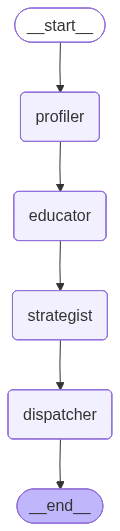

In [6]:
# Show the agent
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))



In [7]:
# Run the Agent
for output in app.stream(inputs):
    print(output)

{'profiler': {'user_profile': {'source': 'TikTok', 'category': 'Bisnis', 'level': 'Awam'}}}
{'educator': {'messages': [AIMessage(content='Berdasarkan kebutuhan armada Anda, saya sarankan OBU F yang bisa memantau BBM & Suhu secara real-time.\nKatalog: https://orin.id/catalog/obu-f-fleet.pdf', additional_kwargs={}, response_metadata={})]}}
{'strategist': {'messages': [AIMessage(content='Saran: Jadwalkan G-Meet dengan tim expert kami untuk demo unit.', additional_kwargs={}, response_metadata={})], 'priority_level': 1}}
{'dispatcher': {'messages': [AIMessage(content='Sistem: Link G-Meet berhasil dibuat: https://meet.google.com/abc-defg-hij', additional_kwargs={}, response_metadata={})]}}


# More Complex

In [121]:
import sqlite3
import json
from typing import Annotated, List, TypedDict, Dict, Optional
from datetime import datetime

from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.sqlite import SqliteSaver

# --- 1. DATABASE & STATE SETUP ---

class CRMState(TypedDict):
    """State yang disimpan di setiap session (Phone Number)"""
    messages: Annotated[List[BaseMessage], lambda x, y: x + y]
    customer_info: Dict        # Data dari SQLite (phone, source, category, needs, etc)
    interaction_stage: str     # PROFILING, EDUCATING, CLOSING, HANDOVER
    last_action: Optional[str]
    
    # WhatsApp Message extra
    wa_move_to_human_agent: bool = False
    wa_send_contact: List = []

# Setup SQLite untuk data permanen (Profil Pelanggan)
def init_db():
    conn = sqlite3.connect("orin_crm.db")
    cursor = conn.cursor()
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS profiles (
            phone_number TEXT PRIMARY KEY,
            source TEXT,
            category TEXT,
            level TEXT,
            needs TEXT,
            is_fleet_prospect BOOLEAN,
            last_interaction TIMESTAMP
        )
    ''')
    conn.commit()
    return conn

# --- 2. TOOLS SPESIFIK WHATSAPP & CRM ---
@tool
def update_crm_profile(phone_number: str, **kwargs):
    """
    Menyimpan atau memperbarui data profiling customer ke SQLite.
    Gunakan ini setiap kali Hana mendapatkan info baru mengenai customer.
    **kwargs tambahan: 
    {
        source: TEXT,
        category: TEXT,
        level: TEXT,
        needs: TEXT,
    }
    """
    conn = sqlite3.connect("orin_crm.db")
    cursor = conn.cursor()
    
    # 1. Bersihkan kwargs dari nilai None jika ada
    updates = {k: v for k, v in kwargs.items() if v is not None}
    
    # 2. Cek apakah user sudah terdaftar
    cursor.execute("SELECT 1 FROM profiles WHERE phone_number = ?", (phone_number,))
    exists = cursor.fetchone()
    
    if not exists:
        # LOGIKA INSERT: Jika data baru
        keys = ["phone_number", "last_interaction"] + list(updates.keys())
        placeholders = ", ".join(["?" for _ in range(len(keys))])
        values = [phone_number, datetime.now()] + list(updates.values())
        
        sql = f"INSERT INTO profiles ({', '.join(keys)}) VALUES ({placeholders})"
        cursor.execute(sql, values)
    else:
        # LOGIKA UPDATE: Jika data sudah ada
        if updates:
            # Bangun query SET secara dinamis hanya jika ada field yang diupdate
            field_query = ", ".join([f"{k} = ?" for k in updates.keys()])
            sql = f"UPDATE profiles SET {field_query}, last_interaction = CURRENT_TIMESTAMP WHERE phone_number = ?"
            values = list(updates.values()) + [phone_number]
            cursor.execute(sql, values)
        else:
            # Jika tidak ada data baru, cukup update timestamp interaksi terakhir
            cursor.execute("UPDATE profiles SET last_interaction = CURRENT_TIMESTAMP WHERE phone_number = ?", (phone_number,))
            
    conn.commit()
    conn.close() # Penting: Tutup koneksi setelah selesai
    return "Profile CRM berhasil diperbarui."

@tool
def check_sales_availability():
    """
    Mengecek tim sales yang standby (Rolling System).
    Mengembalikan nama sales (A-E) atau Senior (Gustama/Oktav) untuk kasus Fleet.
    """
    # Simulasi rolling logic
    import random
    return random.choice(["Sales B", "Sales C", "Gustama (Senior)"])

@tool
def propose_online_meeting() -> str:
    """
    Ajukan meeting online, saat ini fitur ini belum tersedia langsung oleh agent
    jadi langsung setting state wa_move_to_human_agent = True
    """
    # Simulasi rolling logic
    return "Sesi chat dialihkan ke Human Agent"

# --- 3. HANA CORE LOGIC (NODES) ---

class HanaOrchestrator:
    def __init__(self):
        self.llm = ChatOpenAI(model="gpt-4.1", temperature=0)
        self.tools = [update_crm_profile, propose_online_meeting, check_sales_availability]
        self.model_with_tools = self.llm.bind_tools(self.tools)

    def load_context(self, state: CRMState):
        """Node pertama: Mengambil data dari SQLite berdasarkan phone_number"""
        # Phone number didapat dari config thread_id (simulasi)
        phone = "62812345678" 
        conn = sqlite3.connect("orin_crm.db")
        cursor = conn.cursor()
        cursor.execute("SELECT * FROM profiles WHERE phone_number = ?", (phone,))
        row = cursor.fetchone()
        
        profile = {}
        if row:
            profile = {
                "phone": phone,
                "source": row[1],
                "category": row[2],
                "level": row[3],
                "needs": row[4]
            }
        
        return {"customer_info": profile}

    def hana_brain(self, state: CRMState):
        """Hana berpikir dengan proteksi urutan pesan."""
        profile = state.get("customer_info", {})
        
        system_prompt = f"""
        Nama kamu Hana, Customer Service dari ORIN. Kamu asisten yang pintar, ramah, dan solutif.
        
        DATA CUSTOMER SAAT INI:
        {json.dumps(profile)}
        
        TUGAS KAMU:
        -Melakukan profiling
        -Gunakan tools untuk melayani customer
        """
        
        # PERBAIKAN: Gunakan SystemMessage object & pastikan history bersih
        combined_messages = [SystemMessage(content=system_prompt)] + state["messages"]
        
        try:
            response = self.model_with_tools.invoke(combined_messages)
            return {"messages": [response]}
        except Exception as e:
            # Jika OpenAI protes soal urutan, kita bisa log atau handle di sini
            print(f"Error calling LLM: {e}")
            raise e

    def tool_executor(self, state: CRMState):
        """Node eksekusi tool dengan penanganan error per tool call."""
        last_message = state["messages"][-1]
        tool_outputs = []
        state_output: CRMState = {}
        
        if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
            for tool_call in last_message.tool_calls:
                tool_name = tool_call["name"]
                args = tool_call["args"]
                t_id = tool_call["id"] # Ambil ID wajib
                
                try:
                    # Eksekusi tool sesuai nama
                    # if tool_name == "send_wa_message":
                    #     res = send_wa_message.invoke(args)
                    if tool_name == "update_crm_profile":
                        res = update_crm_profile.invoke(args)
                    elif tool_name == "propose_online_meeting":
                        res = propose_online_meeting.invoke(args)
                        state_output["wa_move_to_human_agent"] = True
                    elif tool_name == "check_sales_availability":
                        res = check_sales_availability.invoke(args)
                        state_output["wa_send_contact"] = res
                    else:
                        res = f"Tool {tool_name} tidak ditemukan."
                except Exception as e:
                    # JIKA TOOL ERROR: Kita tetap harus kirim ToolMessage 
                    # agar urutan chat di OpenAI tidak rusak
                    res = f"Error saat menjalankan tool: {str(e)}"
                
                # WAJIB: ToolMessage harus punya tool_call_id yang sesuai
                tool_outputs.append(ToolMessage(tool_call_id=t_id, content=str(res)))
        
        state_output["messages"] = tool_outputs
        return state_output
    
class WhatsAppOrchestrator:
    def __init__(self):
        pass
    
    def send_wa_message(self, state: CRMState):
        """
        Mengirim pesan WhatsApp ke customer. 
        message_type: 'text', 'image', 'document' (untuk katalog), 'sticker'.
        """
        
        phone_number: str = state["customer_info"].get("phone")
        text: str = state["messages"][-1].content
        message_type: str = "text"
        media_url: str = None
        
        # Placeholder: Integrasi dengan API (baileys, open-wa, atau official API)
        print(f"--- [WA SEND] [{message_type}] to {phone_number}: {text} ---")
        return {}



In [122]:
from langgraph.graph import StateGraph, END

def build_hana_graph():
    orchestrator = HanaOrchestrator()
    wa_agent = WhatsAppOrchestrator()
    workflow = StateGraph(CRMState)

    # --- 1. Definisi Nodes dengan Nama Deskriptif ---
    # Nama node yang deskriptif akan muncul di diagram
    workflow.add_node("Retrieve_Profile", orchestrator.load_context)
    workflow.add_node("AI_Decision_Logic", orchestrator.hana_brain)
    workflow.add_node("Execute_CRM_Actions", orchestrator.tool_executor)
    workflow.add_node("Send_WA_Message", wa_agent.send_wa_message)

    # --- 2. Definisi Edges (Alur Tetap) ---
    workflow.set_entry_point("Retrieve_Profile")
    workflow.add_edge("Retrieve_Profile", "AI_Decision_Logic")
    
    # Alur balik dari Tools ke AI untuk konfirmasi (Loopback)
    workflow.add_edge("Execute_CRM_Actions", "AI_Decision_Logic")

    # --- 3. Definisi Conditional Logic (Hanya Satu Kali) ---
    def router_logic(state: CRMState):
        """Logic untuk menentukan jalur berikutnya."""
        last_msg = state["messages"][-1]
        # Jika AI ingin memanggil fungsi/tool
        if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
            return "call_tools"
        # Jika AI sudah memberikan jawaban final ke user
        return "Send_WA_Message"

    # Mapping ini akan muncul sebagai label di garis panah diagram
    workflow.add_conditional_edges(
        "AI_Decision_Logic",
        router_logic,
        {
            "call_tools": "Execute_CRM_Actions",
            "Send_WA_Message": "Send_WA_Message"
        }
    )

    return workflow

# Buat instance workflow-nya
hana_workflow = build_hana_graph()

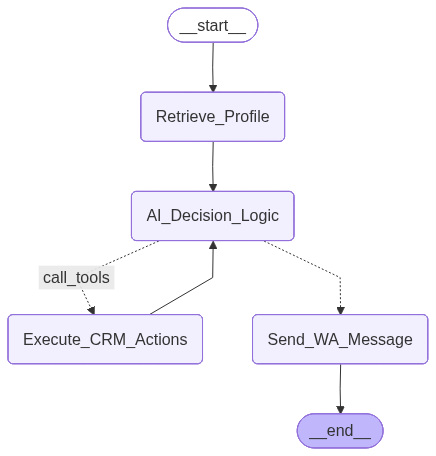

In [58]:
from IPython.display import Image, display

# Kompilasi tanpa checkpointer hanya untuk visualisasi agar tidak butuh context manager
app_vis = hana_workflow.compile()

# Gunakan format Mermaid dengan parameter tambahan untuk kejelasan
display(Image(app_vis.get_graph(xray=True).draw_mermaid_png()))

In [123]:
def run_hana_crm(hana_workflow: StateGraph, user_message: str, phone_number: str):
    # Gunakan workflow yang sudah di-build di luar
    with SqliteSaver.from_conn_string("state_checkpoints.db") as memory:
        app = hana_workflow.compile(checkpointer=memory)
        config = {"configurable": {"thread_id": f"phone_{phone_number}"}}
        
        for chunk in app.stream({"messages": [HumanMessage(content=user_message)]}, config):
            for node, values in chunk.items():
                print(f"Update from node: {node}")
                if values:
                    for msg in values.get("messages", []):
                        msg.pretty_print()
        # return app.invoke(
        #     {"messages": [HumanMessage(content=user_message)]}, 
        #     config
        # )

In [124]:
# --- 5. SIMULASI RUN (1 Pesan = 1 Run) ---

init_db()
app = build_hana_graph()


In [126]:
run_hana_crm(
    hana_workflow=app,
    user_message="halo",
    phone_number="6281234562"
)

Update from node: Retrieve_Profile
Update from node: AI_Decision_Logic
================================== Ai Message ==================================

Halo! Saya Hana, Customer Service dari ORIN. Senang bisa membantu Anda hari ini. Boleh tahu, ada yang bisa saya bantu? Atau mungkin Anda ingin sharing sedikit tentang kebutuhan atau minat Anda, supaya saya bisa memberikan solusi yang paling sesuai? 😊
--- [WA SEND] [text] to None: Halo! Saya Hana, Customer Service dari ORIN. Senang bisa membantu Anda hari ini. Boleh tahu, ada yang bisa saya bantu? Atau mungkin Anda ingin sharing sedikit tentang kebutuhan atau minat Anda, supaya saya bisa memberikan solusi yang paling sesuai? 😊 ---
Update from node: Send_WA_Message


In [7]:
run_hana_crm("Saya dari perusahaan logistik, butuh OBU F", "62812345678")


--- PROCESSING MESSAGE FROM 62812345678 ---
--- [WA SEND] to : Terima kasih sudah menghubungi kami! Untuk kebutuh... ---


/tmp/ipykernel_20294/823232070.py:74: DeprecationWarning: The default datetime adapter is deprecated as of Python 3.12; see the sqlite3 documentation for suggested replacement recipes
  cursor.execute(sql, values)


--- [WA SEND] to : Tim sales kami, Sales C, sedang tersedia dan akan ... ---


{'messages': [HumanMessage(content='Halo Hana, saya ingin tanya-tanya', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hai! 😊 Tentu, ada yang bisa saya bantu? Apakah Anda ingin tahu lebih lanjut tentang produk kami atau ada kebutuhan khusus yang ingin Anda diskusikan?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 371, 'total_tokens': 405, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-CrPub4YOc9k2Xz11EfLl00gPpZeJv', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019b604a-0bd2-7e61-820a-40198380d4db-0', usage_metadata={'input_tokens': 371, 'output_tokens': 34, 'total_tokens': 405, 'input_toke

In [10]:
run_hana_crm("Saya dari perusahaan logistik tertarik dengan device orin", "62812345679")


--- PROCESSING MESSAGE FROM 62812345679 ---


/tmp/ipykernel_20294/823232070.py:74: DeprecationWarning: The default datetime adapter is deprecated as of Python 3.12; see the sqlite3 documentation for suggested replacement recipes
  cursor.execute(sql, values)


--- [WA SEND] to 123456789: Terima kasih atas minat Anda pada device ORIN! 😊 K... ---


{'messages': [HumanMessage(content='Saya dari perusahaan logistik tertarik dengan device orin', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 372, 'total_tokens': 421, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-CrPwjbD6rRNNqvCWuj3fgBbVxLz11', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b604c-12e9-7681-83a2-f2b3b69cac8f-0', tool_calls=[{'name': 'update_crm_profile', 'args': {'phone_number': '123456789'}, 'id': 'call_y8DAPhShdTOExzEbVszZraJb', 'type': 'tool_call'}, {'name': 'check_sales_availability', 'args': {}, 'id': 'call_X2lHL

In [11]:
print("\n--- USER CHAT 1 ---")
app.invoke({
    "messages": [HumanMessage(content="Halo")],
    "interaction_stage": "PROFILING"
}, config)


--- USER CHAT 1 ---


AttributeError: '_GeneratorContextManager' object has no attribute 'get_next_version'

In [ ]:



# Simulasi Chat Kedua: User tanya solusi untuk kantor
print("\n--- USER CHAT 2 ---")
app.invoke({
    "messages": [HumanMessage(content="Saya dari rental mobil PT. Maju Jaya, mau tanya alat buat pantau bensin.")]
}, config)